In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

# Configuration
STANDARD_AMINO_ACIDS = set('ACDEFGHIKLMNPQRSTVWY')
AMINO_ACID_LIST = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L',
                   'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

HYDROPHOBIC_AA = set('AILMFVP')
CHARGED_AA_POS = set('KRH')
CHARGED_AA_NEG = set('DE')
POLAR_AA = set('STNQ')
AROMATIC_AA = set('FWY')

# Load dataset
df = pd.read_csv('/content/drive/My Drive/DATA/pfam_46872x62.csv')
print(f"✓ Loaded: {len(df)} rows × {len(df.columns)} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 3 rows:")
print(df.head(3))

# Column assignment (fixed for your dataset)
seq_col = 'sequence'
id_col = 'structureid'
family_col = 'classification'

print(f"\n✓ Using:")
print(f"  - Sequence: '{seq_col}'")
print(f"  - ID: '{id_col}'")
print(f"  - Family: '{family_col}'")

✓ Loaded: 46872 rows × 3 columns

Columns: ['structureId', 'classification', 'sequence']

First 3 rows:
  structureId classification  \
0        1A9V       ALLERGEN   
1        1AHK       ALLERGEN   
2        1AHM       ALLERGEN   

                                            sequence  
0  SQVDVKDCANHEIKKVLVPGCHGSEPCIIHRGKPFQLEAVFEANQN...  
1  DQVDVKDCANNEIKKVMVDGCHGSDPCIIHRGKPFTLEALFDANQN...  
2  DQVDVKDCANNEIKKVMVDGCHGSDPCIIHRGKPFTLEALFDANQN...  

✓ Using:
  - Sequence: 'sequence'
  - ID: 'structureid'
  - Family: 'classification'


In [ ]:
print("\n" + "="*60)
print("DATA UNDERSTANDING & CLEANING")
print("="*60)

# Initial stats
print(f"\nInitial dataset: {len(df)} sequences")
print(f"Unique sequences: {df[seq_col].nunique()}")
print(f"Unique families: {df[family_col].nunique()}")
print(f"Missing sequences: {df[seq_col].isna().sum()}")
print(f"Missing families: {df[family_col].isna().sum()}")

# Sequence length stats
seq_lengths = df[seq_col].str.len()
print(f"\nSequence Length:")
print(f"  Min: {seq_lengths.min()}")
print(f"  Max: {seq_lengths.max()}")
print(f"  Mean: {seq_lengths.mean():.2f}")
print(f"  Median: {seq_lengths.median():.2f}")
print(f"  Std: {seq_lengths.std():.2f}")

# CLEANING
print(f"\n--- Cleaning Steps ---")
initial_count = len(df)

# Remove missing
df = df[df[seq_col].notna()].copy()
print(f"After removing missing: {len(df)}")

# Normalize sequences
df[seq_col] = df[seq_col].str.upper().str.strip()
print(f"Sequences normalized (uppercase)")

# Remove duplicate sequences (keep first)
df = df[~df[seq_col].duplicated(keep='first')]
print(f"After removing duplicate sequences: {len(df)}")

# Check invalid characters
invalid_mask = df[seq_col].apply(
    lambda x: not all(c in STANDARD_AMINO_ACIDS or c in 'XU' for c in str(x))
)
invalid_count = invalid_mask.sum()
print(f"Invalid sequences found: {invalid_count}")

if invalid_count > 0:
    print(f"  Examples:")
    for idx, row in df[invalid_mask].head(3).iterrows():
        seq = row[seq_col]
        invalid_chars = set(seq) - STANDARD_AMINO_ACIDS - {'X', 'U'}
        print(f"    {seq[:40]}... has {invalid_chars}")

    # Remove if significant
    if invalid_count / len(df) < 0.1:  # Less than 10%
        print(f"  ✓ Keeping (< 10% of data)")
    else:
        print(f"  ✗ Removing ({100*invalid_count/len(df):.1f}% of data)")
        df = df[~invalid_mask]

print(f"\nFinal cleaned: {len(df)} sequences")
print(f"Removed: {initial_count - len(df)} sequences")


DATA UNDERSTANDING & CLEANING

Initial dataset: 46872 sequences
Unique sequences: 31911
Unique families: 62
Missing sequences: 0
Missing families: 0

Sequence Length:
  Min: 100
  Max: 1000
  Mean: 313.44
  Median: 268.00
  Std: 183.60

--- Cleaning Steps ---
After removing missing: 46872
Sequences normalized (uppercase)
After removing duplicate sequences: 31911
Invalid sequences found: 3
  Examples:
    MEQQPLTLTAATTRAQELRKQLNQYSHEYYVKDQPSVEDY... has {'Z'}
    TTPLVHVASVEKGRSYEDFQKVYNAIALKLREDDEYDNYI... has {'B'}
    ANSVCFTFTDFESGQQDLIFQGDASVGSNKALQLTKVDSK... has {'B'}
  ✓ Keeping (< 10% of data)

Final cleaned: 31911 sequences
Removed: 14961 sequences



OUTLIER DETECTION (Sequence Length)

IQR Method:
  Q1=168, Q3=406, IQR=238
  Bounds: [-189, 763]
  Outliers: 1415 (4.43%)

Z-Score Method (|Z| > 3):
  Outliers: 515 (1.61%)

Combined: 1415 outliers detected


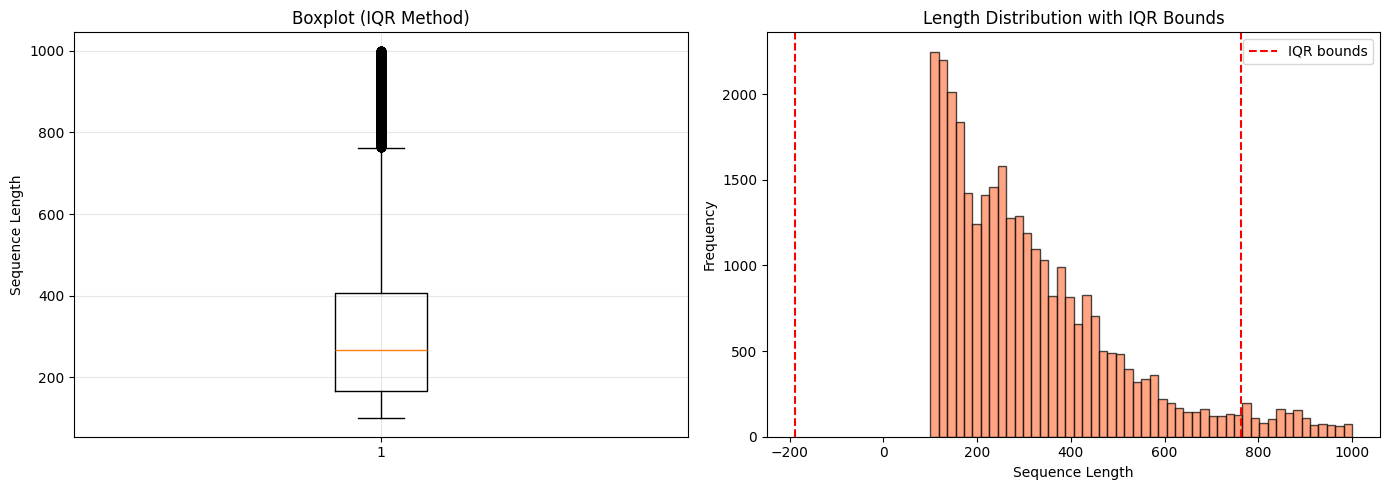


✓ Outliers kept (use remove_outliers=True to exclude)


In [ ]:
print("\n" + "="*60)
print("OUTLIER DETECTION (Sequence Length)")
print("="*60)

seq_lengths = df[seq_col].str.len()

# IQR Method
Q1 = seq_lengths.quantile(0.25)
Q3 = seq_lengths.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = (seq_lengths < lower_bound) | (seq_lengths > upper_bound)

print(f"\nIQR Method:")
print(f"  Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f}")
print(f"  Bounds: [{lower_bound:.0f}, {upper_bound:.0f}]")
print(f"  Outliers: {iqr_outliers.sum()} ({100*iqr_outliers.sum()/len(df):.2f}%)")

# Z-score Method
mean_len = seq_lengths.mean()
std_len = seq_lengths.std()
z_scores = np.abs((seq_lengths - mean_len) / std_len)
z_outliers = z_scores > 3
print(f"\nZ-Score Method (|Z| > 3):")
print(f"  Outliers: {z_outliers.sum()} ({100*z_outliers.sum()/len(df):.2f}%)")

# Combined
all_outliers = iqr_outliers | z_outliers
print(f"\nCombined: {all_outliers.sum()} outliers detected")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(seq_lengths, vert=True)
axes[0].set_ylabel('Sequence Length')
axes[0].set_title('Boxplot (IQR Method)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(seq_lengths, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(lower_bound, color='red', linestyle='--', label=f'IQR bounds')
axes[1].axvline(upper_bound, color='red', linestyle='--')
axes[1].set_xlabel('Sequence Length')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Length Distribution with IQR Bounds')
axes[1].legend()

plt.tight_layout()
plt.show()

# Option to remove (set to True if needed)
remove_outliers = False
if remove_outliers and all_outliers.sum() > 0:
    df = df[~all_outliers]
    print(f"\n✓ Outliers removed. Remaining: {len(df)}")
else:
    print(f"\n✓ Outliers kept (use remove_outliers=True to exclude)")


EXPLORATORY DATA ANALYSIS (EDA)


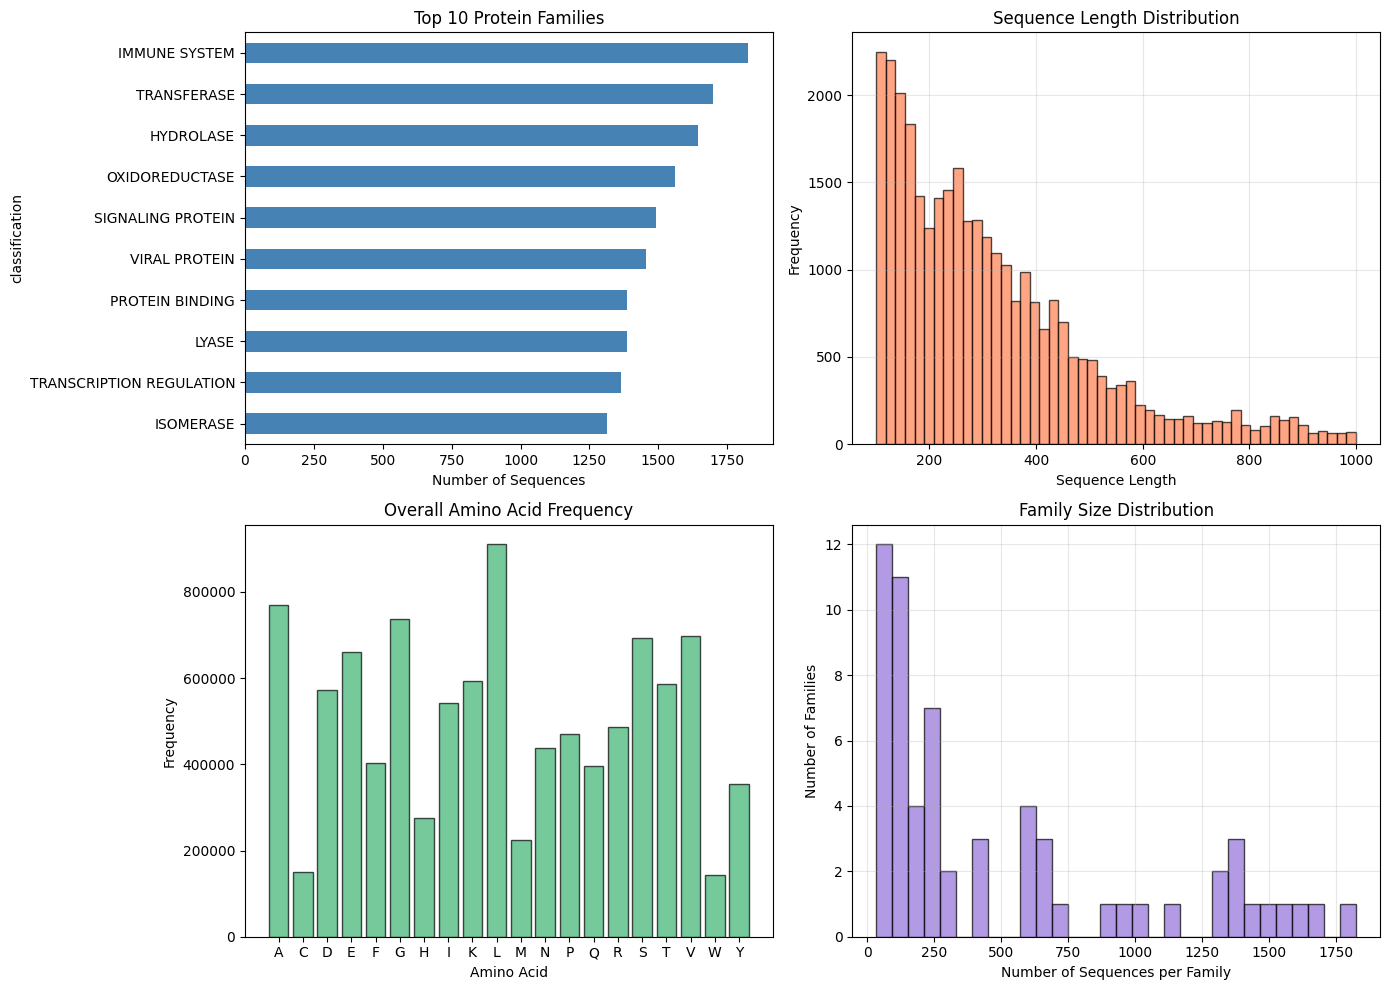


Dataset Summary:
  Sequences: 31911
  Families: 62
  Avg sequences per family: 514.7


In [ ]:
print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Family Distribution (Top 10)
family_counts = df[family_col].value_counts().head(10)
family_counts.plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_xlabel('Number of Sequences')
axes[0, 0].set_title('Top 10 Protein Families')
axes[0, 0].invert_yaxis()

# Plot 2: Sequence Length Distribution
seq_lengths = df[seq_col].str.len()
axes[0, 1].hist(seq_lengths, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Sequence Length')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Sequence Length Distribution')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Amino Acid Frequency
all_aa = ''.join(df[seq_col].values)
aa_freq = Counter(all_aa)
aa_counts = [aa_freq.get(aa, 0) for aa in AMINO_ACID_LIST]
axes[1, 0].bar(AMINO_ACID_LIST, aa_counts, color='mediumseagreen', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Amino Acid')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Overall Amino Acid Frequency')
axes[1, 0].tick_params(axis='x', rotation=0)

# Plot 4: Family Size Distribution
family_sizes = df[family_col].value_counts()
axes[1, 1].hist(family_sizes, bins=30, color='mediumpurple', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Number of Sequences per Family')
axes[1, 1].set_ylabel('Number of Families')
axes[1, 1].set_title('Family Size Distribution')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDataset Summary:")
print(f"  Sequences: {len(df)}")
print(f"  Families: {df[family_col].nunique()}")
print(f"  Avg sequences per family: {len(df) / df[family_col].nunique():.1f}")

In [ ]:
print("\n" + "="*60)
print("FEATURE EXTRACTION")
print("="*60)

def extract_aa_composition(sequences):
    """20 amino acid composition features"""
    features = []
    for seq in sequences:
        f = {}
        total = len(seq)
        for aa in AMINO_ACID_LIST:
            f[f'{aa}_freq'] = seq.count(aa) / total if total > 0 else 0
        features.append(f)
    return pd.DataFrame(features)

def extract_sequence_features(sequences):
    """Sequence-level features"""
    features = []
    for seq in sequences:
        total = len(seq)
        f = {
            'seq_length': total,
            'pct_hydrophobic': sum(1 for aa in seq if aa in HYDROPHOBIC_AA) / total if total > 0 else 0,
            'pct_charged': sum(1 for aa in seq if aa in CHARGED_AA_POS or aa in CHARGED_AA_NEG) / total if total > 0 else 0,
            'pct_polar': sum(1 for aa in seq if aa in POLAR_AA) / total if total > 0 else 0,
            'pct_aromatic': sum(1 for aa in seq if aa in AROMATIC_AA) / total if total > 0 else 0,
        }
        features.append(f)
    return pd.DataFrame(features)

def extract_kmer_features(sequences, k=2):
    """k-mer frequency features (top 50)"""
    print(f"  Extracting {k}-mers...")

    # Get all kmers
    all_kmers = Counter()
    for seq in sequences:
        kmers = [seq[i:i+k] for i in range(len(seq) - k + 1)]
        all_kmers.update(kmers)

    # Top 50 most common
    top_kmers = [kmer for kmer, _ in all_kmers.most_common(50)]
    print(f"    Using top 50 {k}-mers out of {len(all_kmers)} unique")

    # Extract features
    features = []
    for seq in sequences:
        kmers = [seq[i:i+k] for i in range(len(seq) - k + 1)]
        kmer_counts = Counter(kmers)
        total = len(kmers) if kmers else 1
        f = {f'kmer_{kmer}': kmer_counts.get(kmer, 0) / total for kmer in top_kmers}
        features.append(f)

    return pd.DataFrame(features)

# Extract
sequences = df[seq_col].values

print("\n1. Amino Acid Composition (20 features)")
aa_feat = extract_aa_composition(sequences)
print(f"   ✓ {aa_feat.shape[1]} features")

print("\n2. Sequence Features (5 features)")
seq_feat = extract_sequence_features(sequences)
print(f"   ✓ {seq_feat.shape[1]} features")

print("\n3. k-mer Features (default k=2)")
kmer_feat = extract_kmer_features(sequences, k=2)
print(f"   ✓ {kmer_feat.shape[1]} features")

# Combine
feature_matrix = pd.concat([aa_feat, seq_feat, kmer_feat], axis=1)
print(f"\n✓ TOTAL FEATURES: {feature_matrix.shape[1]}")
print(f"✓ Feature matrix: {feature_matrix.shape[0]} × {feature_matrix.shape[1]}")


FEATURE EXTRACTION

1. Amino Acid Composition (20 features)
   ✓ 20 features

2. Sequence Features (5 features)
   ✓ 5 features

3. k-mer Features (default k=2)
  Extracting 2-mers...
    Using top 50 2-mers out of 461 unique
   ✓ 50 features

✓ TOTAL FEATURES: 75
✓ Feature matrix: 31911 × 75



FEATURE ANALYSIS & STATISTICS

Feature Statistics (first 10):
             A_freq        C_freq        D_freq        E_freq        F_freq  \
count  31911.000000  31911.000000  31911.000000  31911.000000  31911.000000   
mean       0.076049      0.014772      0.056984      0.067324      0.039436   
std        0.032921      0.015624      0.017968      0.024846      0.015774   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.053279      0.004717      0.045113      0.050584      0.028846   
50%        0.070312      0.011976      0.056140      0.066132      0.038202   
75%        0.094488      0.020000      0.067708      0.081301      0.049261   
max        1.000000      0.264706      0.180233      0.268657      0.134293   

             G_freq        H_freq        I_freq        K_freq        L_freq  
count  31911.000000  31911.000000  31911.000000  31911.000000  31911.000000  
mean       0.073326      0.028278      0.054243      0.060675      0.

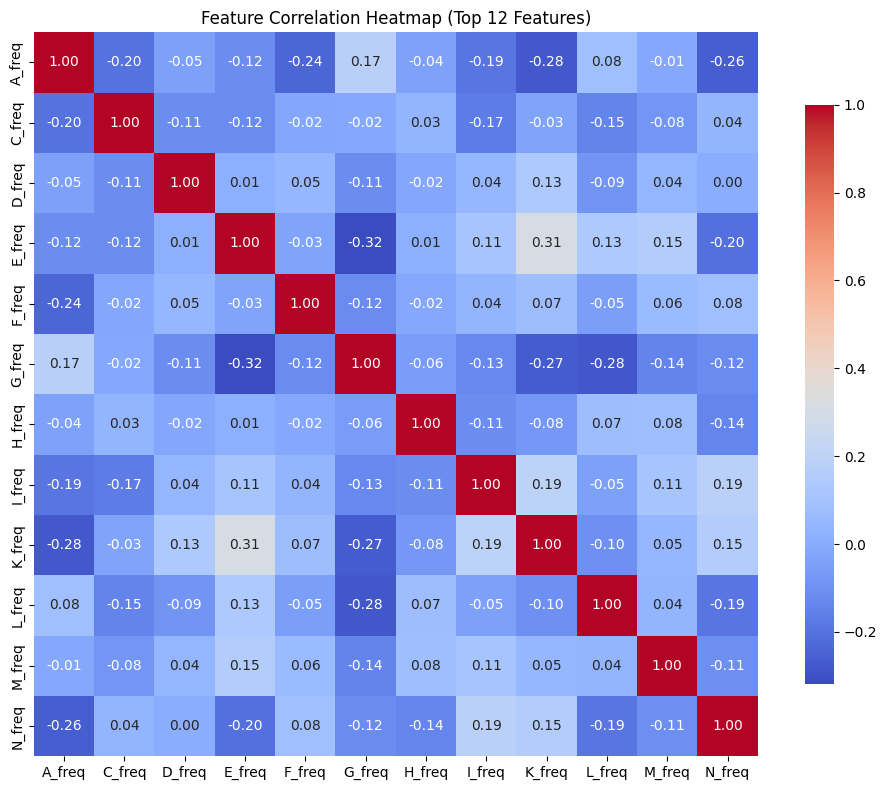

In [ ]:
print("\n" + "="*60)
print("FEATURE ANALYSIS & STATISTICS")
print("="*60)

print(f"\nFeature Statistics (first 10):")
print(feature_matrix.iloc[:, :10].describe())

# Correlation (subset)
print(f"\nCorrelation Analysis (top 12 features)...")
top_features = feature_matrix.columns[:12]
corr_matrix = feature_matrix[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap (Top 12 Features)')
plt.tight_layout()
plt.show()


FEATURE IMPORTANCE (Mutual Information)
Classes: 62 protein families
Samples: 31911 sequences

Calculating MI for 75 features...

Top 15 Most Important Features:
     feature  importance
      C_freq    0.423363
      E_freq    0.419493
   pct_polar    0.411584
      T_freq    0.411499
      L_freq    0.410218
      G_freq    0.406965
      S_freq    0.405613
      W_freq    0.395559
  seq_length    0.393381
      P_freq    0.390361
      M_freq    0.389427
pct_aromatic    0.387746
      R_freq    0.384243
 pct_charged    0.380896
      Y_freq    0.374464


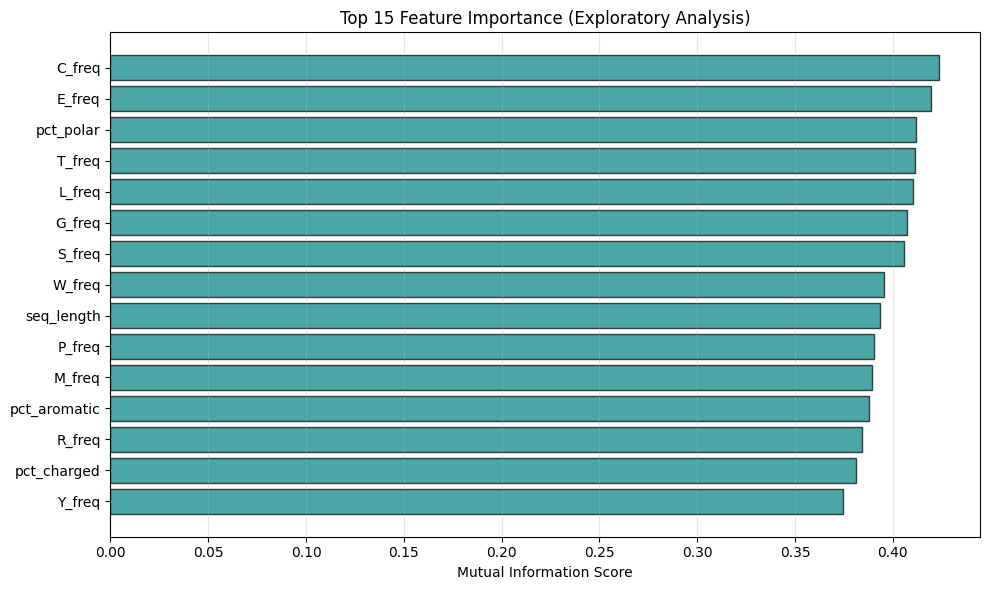

In [ ]:
print("\n" + "="*60)
print("FEATURE IMPORTANCE (Mutual Information)")
print("="*60)

# Encode family labels
le = LabelEncoder()
y_encoded = le.fit_transform(df[family_col])

print(f"Classes: {len(le.classes_)} protein families")
print(f"Samples: {len(y_encoded)} sequences")

# Select numeric features
X = feature_matrix.select_dtypes(include=[np.number]).fillna(0)

# Calculate mutual information
print(f"\nCalculating MI for {X.shape[1]} features...")
mi_scores = mutual_info_classif(X, y_encoded, random_state=42)

# Create dataframe
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': mi_scores
}).sort_values('importance', ascending=False)

print(f"\nTop 15 Most Important Features:")
print(importance_df.head(15).to_string(index=False))

# Visualization
plt.figure(figsize=(10, 6))
top_15 = importance_df.head(15)
plt.barh(range(len(top_15)), top_15['importance'], color='teal', alpha=0.7, edgecolor='black')
plt.yticks(range(len(top_15)), top_15['feature'])
plt.xlabel('Mutual Information Score')
plt.title('Top 15 Feature Importance (Exploratory Analysis)')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*70)
print("FINAL DATA QUALITY & FEATURE EXTRACTION REPORT")
print("="*70)

print(f"\n{'Metric':<45} {'Value':<20}")
print(f"{'-'*65}")
print(f"{'Original dataset':<45} {initial_count:<20}")
print(f"{'Final cleaned sequences':<45} {len(df):<20}")
print(f"{'Sequences removed':<45} {initial_count - len(df):<20}")
print(f"\n{'Sequence Length (Final)':<45}")
print(f"{'  Min - Max':<45} {seq_lengths.min()} - {seq_lengths.max()}")
print(f"{'  Mean':<45} {seq_lengths.mean():.2f}")
print(f"{'  Median':<45} {seq_lengths.median():.2f}")
print(f"\n{'Protein Families':<45} {df[family_col].nunique():<20}")
print(f"{'Extracted Features':<45} {feature_matrix.shape[1]:<20}")
print(f"{'  - Amino acid composition':<45} {aa_feat.shape[1]:<20}")
print(f"{'  - Sequence features':<45} {seq_feat.shape[1]:<20}")
print(f"{'  - k-mer features (k=2)':<45} {kmer_feat.shape[1]:<20}")

print(f"\n{'Feature Matrix Dimensions':<45} {feature_matrix.shape[0]} × {feature_matrix.shape[1]}")
print(f"\n" + "="*70)
print("✓ PREPROCESSING COMPLETE")
print("="*70)


FINAL DATA QUALITY & FEATURE EXTRACTION REPORT

Metric                                        Value               
-----------------------------------------------------------------
Original dataset                              46872               
Final cleaned sequences                       31911               
Sequences removed                             14961               

Sequence Length (Final)                      
  Min - Max                                   100 - 1000
  Mean                                        316.77
  Median                                      268.00

Protein Families                              62                  
Extracted Features                            75                  
  - Amino acid composition                    20                  
  - Sequence features                         5                   
  - k-mer features (k=2)                      50                  

Feature Matrix Dimensions                     31911 × 75

✓ PREPROCESS